<a href="https://colab.research.google.com/github/jwliu24/Uber-Operational-Analysis/blob/main/Week_2_Exploring_the_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handling Missing Values & Feature Preparation
---


In this session, we’ll take a closer look at missing (null) values in the dataset and decide how to handle them based on how the data will be used later.

The goal is to prepare a dataset that is:

- Easy to analyze

- Ready for modeling and product metrics



### Load the dataset

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
import pandas as pd

# Update the file path below to match where your dataset is stored
# Example: '/content/drive/MyDrive/build-project/uber_rides_data.csv'
file_path = '/content/drive/MyDrive/Colab Notebooks/uber_rides_data.csv'


df = pd.read_csv(file_path)

# Display the first few rows of the dataset
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Payment Method,is_successful,is_cancelled_customer,is_cancelled_driver,is_incomplete,DateTime,Hour,DayOfWeek,Month,IsWeekend
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,False,False,False,False,2024-03-23 12:29:38,12,Saturday,3,True
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,UPI,False,False,False,True,2024-11-29 18:01:39,18,Friday,11,False
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,Debit Card,True,False,False,False,2024-08-23 08:56:10,8,Friday,8,False
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,UPI,True,False,False,False,2024-10-21 17:17:25,17,Monday,10,False
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,UPI,True,False,False,False,2024-09-16 22:08:00,22,Monday,9,False


### Data Schema

| Column Name                           | Description                                                                         |
| ------------------------------------- | ----------------------------------------------------------------------------------- |
| **Date**                              | Date of the booking                                                                 |
| **Time**                              | Time of the booking                                                                 |
| **Booking ID**                        | Unique identifier for each ride booking                                             |
| **Booking Status**                    | Status of the booking (Completed, Cancelled by Customer, Cancelled by Driver, etc.) |
| **Customer ID**                       | Unique identifier for customers                                                     |
| **Vehicle Type**                      | Type of vehicle (Go Mini, Go Sedan, Auto, eBike/Bike, UberXL, Premier Sedan)        |
| **Pickup Location**                   | Starting location of the ride                                                       |
| **Drop Location**                     | Destination location of the ride                                                    |
| **Avg VTAT**                          | Average time for driver to reach pickup location (in minutes)                       |
| **Avg CTAT**                          | Average trip duration from pickup to destination (in minutes)                       |
| **Cancelled Rides by Customer**       | Flag indicating customer-initiated cancellation                                     |
| **Reason for cancelling by Customer** | Reason provided for customer cancellation                                           |
| **Cancelled Rides by Driver**         | Flag indicating driver-initiated cancellation                                       |
| **Driver Cancellation Reason**        | Reason provided for driver cancellation                                             |
| **Incomplete Rides**                  | Flag indicating incomplete rides                                                    |
| **Incomplete Rides Reason**           | Reason for incomplete rides                                                         |
| **Booking Value**                     | Total fare amount for the ride                                                      |
| **Ride Distance**                     | Distance covered during the ride (in kilometers)                                    |
| **Driver Ratings**                    | Rating given to the driver (1–5 scale)                                              |
| **Customer Rating**                   | Rating given by the customer (1–5 scale)                                            |
| **Payment Method**                    | Method used for payment (UPI, Cash, Credit Card, Uber Wallet, Debit Card)           |


### Initial Dataset Inspection
Before cleaning or transforming the data, it’s important to understand what we’re working with. In this step, you’ll examine the dataset’s structure, data types, summary statistics, and missing values.

This helps answer questions like:

- What columns exist and what do they represent?

- Which columns are numeric vs. categorical?

- Where are potential data quality issues?

In [47]:
# Review dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 30 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [48]:
# Review Summary Statistics
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Hour,Month
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000,150000.000000,150000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584,14.034113,6.490940
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819,5.416906,3.444028
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000,0.000000,1.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000,10.000000,3.000000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000,15.000000,7.000000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000,18.000000,9.000000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000,23.000000,12.000000


In [49]:
# Quick stats on non-numeric data
df.describe(include=[object])

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Payment Method,DateTime,DayOfWeek
count,150000,150000,150000,150000,150000,150000,150000,150000,10500,27000,9000,102000,150000,150000
unique,365,62910,148767,5,148788,7,176,176,5,4,3,5,149532,7
top,2024-11-16,17:44:57,"""CNR6337479""",Completed,"""CID6715450""",Auto,Khandsa,Ashram,Wrong Address,Customer related issue,Customer Demand,UPI,2024-01-13 09:16:53,Monday
freq,462,16,3,93000,3,37419,949,936,2362,6837,3040,45909,3,21644


In [50]:
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")

print(f"\nVehicle Type Distribution:")
print(df['Vehicle Type'].value_counts())

print(f"\nBooking Status Distribution:")
print(df['Booking Status'].value_counts())

print(f"\nPayment Method Distribution:")
print(df['Payment Method'].value_counts())

Date range: 2024-01-01 to 2024-12-30
Unique customers: 148,788

Vehicle Type Distribution:
Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

Booking Status Distribution:
Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

Payment Method Distribution:
Payment Method
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64


🔍 Checkpoint 1: What other columns have categorical values that you could be interested in? Can they used to make helpful descisions for any future analysis?




Checkpoint 1 response: Beyond status and type, the Reason for cancelling (Customer/Driver) and Location columns are critical. Analyzing Cancellation Reasons allows us to distinguish between 'Behavioral Issues' (Driver not moving) and 'Technical/Quality Issues' (AC not working). Furthermore, Location data can be used to identify 'Black Zones' where supply consistently fails to meet demand, helping in tactical driver repositioning.

### Check for Missing Values

In [51]:
# Check for missing values
df.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


🔍 Checkpoint 2: Understanding Missing Values

Before cleaning anything, pause and think:

- Which columns have the most missing values?

Do you think these values are missing because:

- The data was not collected?

- The event never happened?

- The value is not applicable?

Write your thoughts below:
*(1–2 sentences is enough)*

> Hint: Look at cancellation-related and trip-related columns.




Checkpoint 2 response: The columns with the highest missing values are: Incomplete Rides / Reason, Cancelled Rides by Customer / Reason, Cancelled Rides by Driver / Reason. The majority of missing values occure because the events never happened. Specifically, cancellation and incomplete ride reasons are null because most rides were completed successfully.

### Understand Why Values Are Missing

Before filling or dropping anything, ask:

> Is this value missing because the event never happened? Or because data was not recorded?

Example Patterns You’ll Notice

- **Cancellation-related columns**

These are only filled when a ride is cancelled. If a ride is completed, cancellation reason is naturally missing. These nulls are informative, not errors.

- **Trip metrics (Avg CTAT, Ride Distance, Booking Value)**

These are missing for rides that never completed.
No completed trip → no distance, duration, or fare.

- **Ratings**

Ratings are only given after completed rides.
Missing data means the rating opportunity never occurred.



**Not all missing values should be filled. Some represent real-world logic.**

### Prepping dataset

In [52]:
# Make a copy to avoid modifying original
df_processed = df.copy()

In [53]:
# Create helpful flags
df_processed['is_successful'] = df_processed['Booking Status'] == 'Completed'
df_processed['is_cancelled_customer'] = df_processed['Cancelled Rides by Customer'].notna()
df_processed['is_cancelled_driver'] = df_processed['Cancelled Rides by Driver'].notna()
df_processed['is_incomplete'] = df_processed['Booking Status'] == 'Incomplete'

In [54]:
# Convert dates and times
df_processed['Date'] = pd.to_datetime(df_processed['Date'])
df_processed['DateTime'] = pd.to_datetime(df_processed['Date'].astype(str) + ' ' + df_processed['Time'].astype(str))

# Extract time features
df_processed['Hour'] = df_processed['DateTime'].dt.hour
df_processed['DayOfWeek'] = df_processed['DateTime'].dt.day_name()
df_processed['Month'] = df_processed['DateTime'].dt.month
df_processed['IsWeekend'] = df_processed['DateTime'].dt.weekday >= 5

In [55]:
df_processed.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Payment Method,is_successful,is_cancelled_customer,is_cancelled_driver,is_incomplete,DateTime,Hour,DayOfWeek,Month,IsWeekend
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,False,False,False,False,2024-03-23 12:29:38,12,Saturday,3,True
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,UPI,False,False,False,True,2024-11-29 18:01:39,18,Friday,11,False
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,Debit Card,True,False,False,False,2024-08-23 08:56:10,8,Friday,8,False
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,UPI,True,False,False,False,2024-10-21 17:17:25,17,Monday,10,False
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,UPI,True,False,False,False,2024-09-16 22:08:00,22,Monday,9,False


In [56]:
df_processed.to_csv('/content/drive/MyDrive/Colab Notebooks/uber_rides_data.csv', index=False)

🔍 Checkpoint 3: Create One New Feature

Objective:
Practice thinking like a data scientist by creating a feature that could be useful later.

Task:
Create one new column that could help with:

- Product metrics or

- Predictive modeling

In [58]:
df_processed = df.copy()

In [59]:
# create new feature: Trip Speed (km/h)
# formula: (Distance / Time in minutes) * 60
df_processed['Trip_Speed_KMH'] = (df_processed['Ride Distance'] / df_processed['Avg CTAT']) * 60

In [60]:
# create 'Is_Rush_Hour' for predictive modeling goal
# Morning 8-10AM and Evening 5-8pm
df_processed['Pickup_Timestamp'] = pd.to_datetime(df_processed['Date'] + ' ' + df_processed['Time'])
df_processed['Hour'] = df_processed['Pickup_Timestamp'].dt.hour
df_processed['Is_Rush_Hour'] = df_processed['Hour'].isin([8, 9, 10, 17, 18,19,20])

In [61]:
# display results for completed rides
print('New Features for Completed Rides:')
df_processed[df_processed['Booking Status'] == 'Completed'][['Booking ID', 'Trip_Speed_KMH', 'Is_Rush_Hour']].head()

New Features for Completed Rides:


,Booking ID,Trip_Speed_KMH,Is_Rush_Hour
2,"""CNR8494506""",31.581395,True
3,"""CNR8906825""",71.621053,True
4,"""CNR1950162""",147.581633,False
5,"""CNR4096693""",16.077348,True
6,"""CNR2002539""",121.294118,False


Checkpoint 3 response: I created the feature Trip_Speed_KMH. This is useful for product metrics because it identifies locations with high traffic congestion. I also added Is_Rush_Hour, which will be a key input for my predictive model to determine if time-of-day is a major factor in ride cancellations.

In [62]:
# show the average cancellation rate for different wait times
df_processed = df.copy()

In [63]:
#create the 'Wait_Time_Bucket'
def get_vtat_bucket(vtat):
  if pd.isna(vtat): return 'N/A (No Driver)'
  if vtat <= 5: return '0-5 min (Fast)'
  if vtat <= 10: return '5-10 min (Average)'
  if vtat <= 15: return '10-15 min (Slow)'
  return '15+ min (Very Slow)'

In [64]:
# apply the bucket logic
df_processed['Wait_Time_Bucket'] = df_processed['Avg VTAT'].apply(get_vtat_bucket)

# create the Binary Flags
df_processed['Wait_Time_Bucket'] = df_processed['Avg VTAT'].apply(get_vtat_bucket)
df_processed['is_successful'] = df_processed['Booking Status'] == 'Completed'
df_processed['is_cancelled_customer'] = df_processed['Cancelled Rides by Customer'].notna()
df_processed['is_cancelled_driver'] = df_processed['Cancelled Rides by Driver'].notna()
df_processed['is_incomplete'] = df_processed['Booking Status'] == 'Incomplete'
df_processed['is_no_driver'] = df_processed['Booking Status'] == 'No Driver Found'

In [65]:
# verify and analyze
print("--- Flag Summary ---")
print(df_processed[['is_successful', 'is_cancelled_customer', 'is_no_driver']].sum())

print("--- Customer Cancellation Rate by Wait Time ---")
analysis = df_processed.groupby('Wait_Time_Bucket')['is_cancelled_customer'].mean() * 100
print(analysis)

--- Flag Summary ---
is_successful            93000
is_cancelled_customer    10500
is_no_driver             10500
dtype: int64
--- Customer Cancellation Rate by Wait Time ---
Wait_Time_Bucket
0-5 min (Fast)           0.105394
10-15 min (Slow)         7.678906
15+ min (Very Slow)    100.000000
5-10 min (Average)       5.856818
N/A (No Driver)          0.000000
Name: is_cancelled_customer, dtype: float64


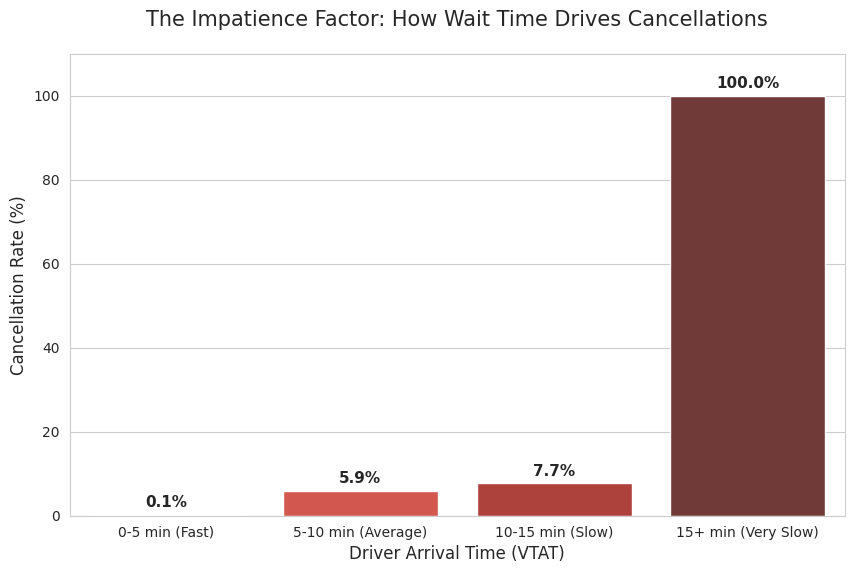

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# prepare the data for plotting
order = ['0-5 min (Fast)', '5-10 min (Average)', '10-15 min (Slow)', '15+ min (Very Slow)']
plot_data = analysis.reindex(order)

# create the plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# reate the bar chart
ax = sns.barplot(x=plot_data.index, y=plot_data.values, hue=plot_data.index, palette='Reds_d', legend=False)

# add labels and Title
plt.title('The Impatience Factor: How Wait Time Drives Cancellations', fontsize=15, pad=20)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.xlabel('Driver Arrival Time (VTAT)', fontsize=12)
plt.ylim(0, 110) # Set to 110 to give room for the 100% bar

# add data labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.show()

Insight: While cancellation rates remain manageable (under 10%) for wait times up to 15 minutes, they jump to 100% the moment the wait exceeds that mark.